In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split, cross_validate
# from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier # 1
from sklearn.metrics import confusion_matrix,roc_curve,auc, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier # 2
from sklearn.linear_model import LogisticRegression# 3
import matplotlib.pyplot as plt

## Data cleaning and exploratory data analysis

In [3]:

iris=pd.read_csv('IRIS (1).csv')

In [4]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
iris.species.value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: species, dtype: int64

In [8]:
iris.sepal_length.describe()

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: sepal_length, dtype: float64

In [9]:
iris[['sepal_length','sepal_width','petal_length','petal_width']].mean()

sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width     1.198667
dtype: float64

In [35]:
iris.corr()

C:\Users\user\AppData\Local\Temp\ipykernel_8944\2141086772.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  iris.corr()


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [37]:
import seaborn as sns

C:\Users\user\AppData\Local\Temp\ipykernel_8944\1935535257.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(iris.corr(),annot=True, cmap='Greens')


Text(0.5, 1.0, 'Correlation plot')

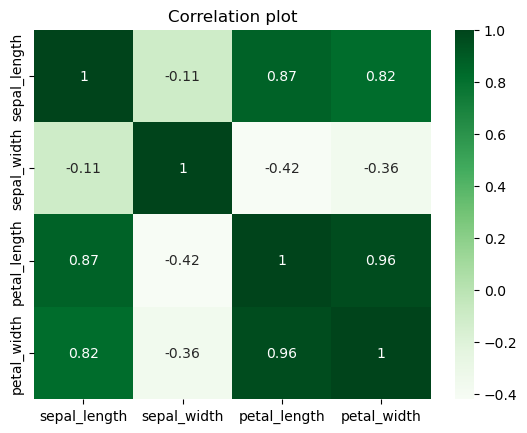

In [47]:
sns.heatmap(iris.corr(),annot=True, cmap='Greens')
plt.title('Correlation plot')

<Axes: >

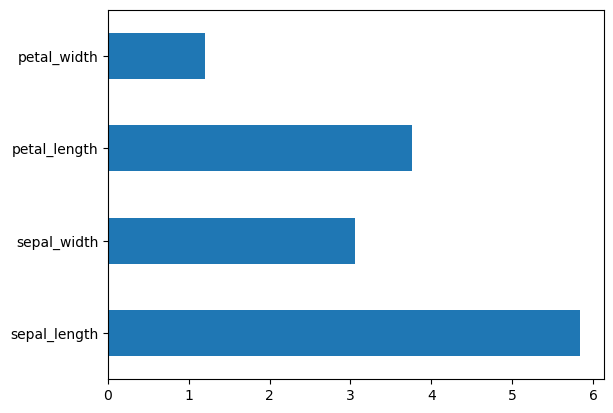

In [10]:
iris[['sepal_length','sepal_width','petal_length','petal_width']].mean().plot(kind='barh')

     ## Spliting ou data set into x-input and y-output 

In [11]:
x=iris.drop(columns=['species'],axis=1)
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [12]:
y=iris.species
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object

## spliting data into x-input,y-output

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [14]:
x_train.shape

(120, 4)

In [15]:
x_test.shape

(30, 4)

## Training the machine learning model with our dataset(supervised learning)

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
rfc=RandomForestClassifier()

In [18]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

## Testing our machine learning model using accuracy score

In [19]:
y_pred=rfc.predict(x_test)

In [20]:
accuracy=accuracy_score(y_test,y_pred)

In [21]:
accuracy

0.9333333333333333

In [34]:
{f'The accuracy of machine learning model using the iris species dataset is {accuracy*100}'}

{'The accuracy of machine learning model using the iris species dataset is 93.33333333333333'}

### Testing our machine learning model using confusion matrix

In [74]:
 matrix=confusion_matrix(y_test,y_pred)
 matrix

array([[ 9,  0,  0],
       [ 0, 10,  2],
       [ 0,  0,  9]], dtype=int64)